# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")   # your file name in VS Code

print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

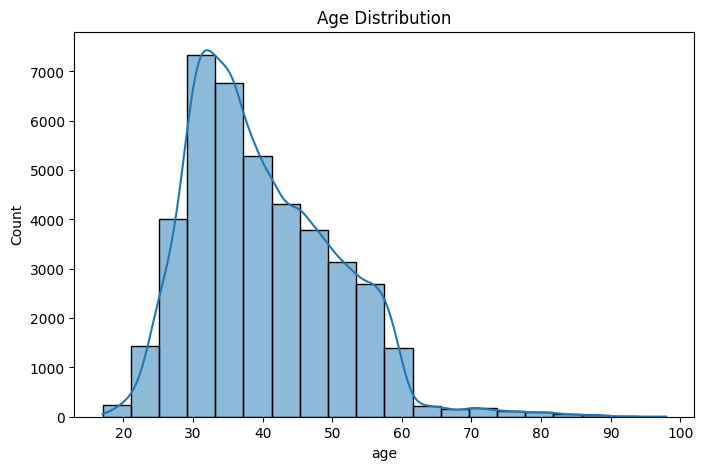

In [14]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


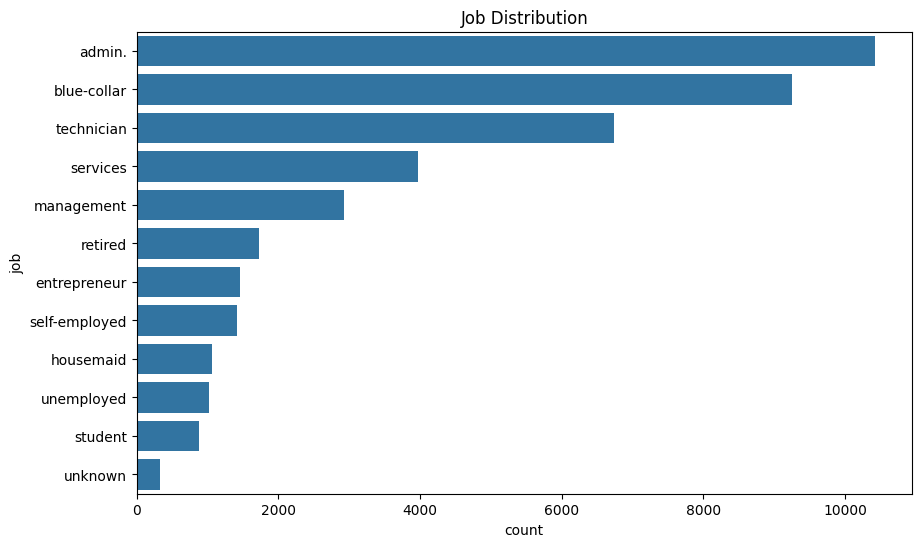

In [15]:
# Job distribution
plt.figure(figsize=(10,6))
sns.countplot(y="job", data=df,
              order=df["job"].value_counts().index)
plt.title("Job Distribution")
plt.show()


## Balance & Deposit Trends

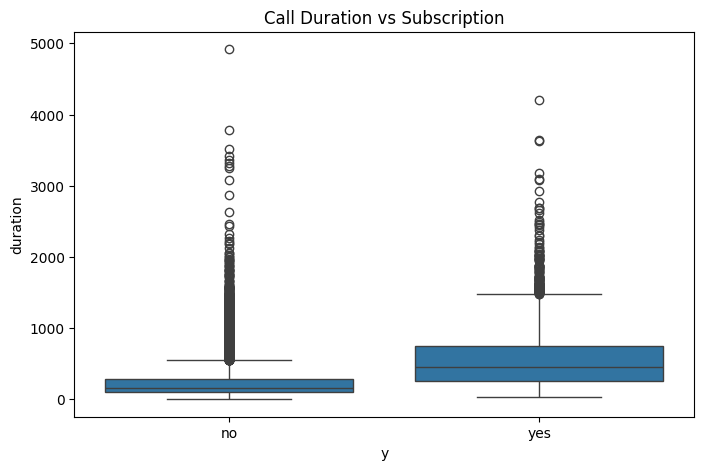

In [16]:
# Average balance by deposit subscription
plt.figure(figsize=(8,5))
sns.boxplot(x="y", y="duration", data=df)
plt.title("Call Duration vs Subscription")
plt.show()

## Campaign Effectiveness

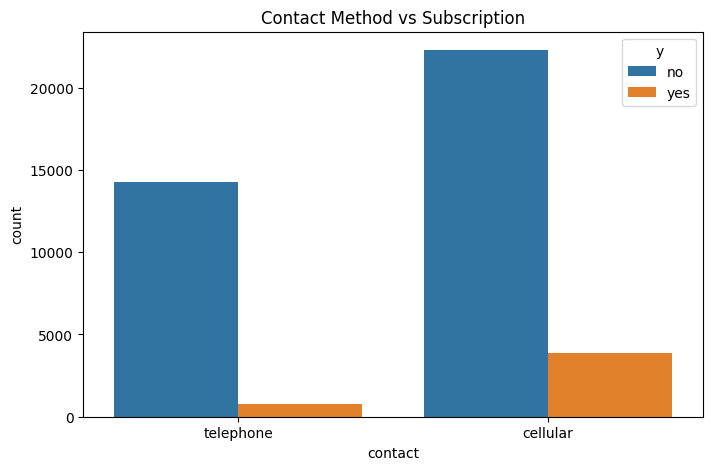

In [17]:
# Contact method analysis
plt.figure(figsize=(8,5))
sns.countplot(x="contact", hue="y", data=df)
plt.title("Contact Method vs Subscription")
plt.show()

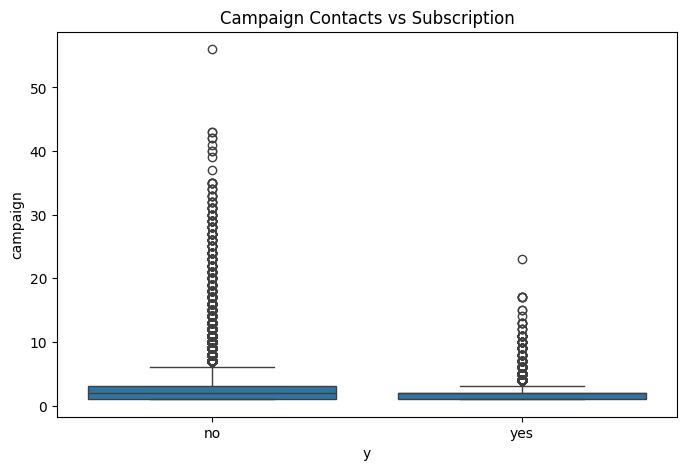

In [18]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(8,5))
sns.boxplot(x="y", y="campaign", data=df)
plt.title("Campaign Contacts vs Subscription")
plt.show()


## Correlation Heatmap

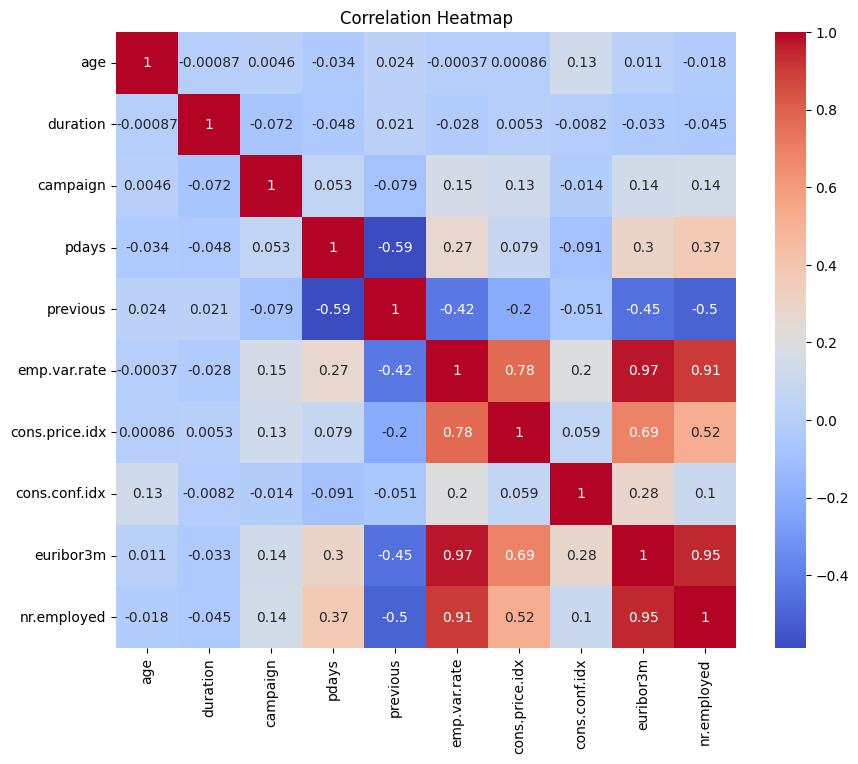

In [19]:
# Correlation of numerical variables
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

## Predictive Modeling (Logistic Regression)

In [20]:


# Encode categorical variables

# Predictions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df_model = pd.get_dummies(df, drop_first=True)
y = df_model["y_yes"]

X = df_model.drop("y_yes", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.9106579266812334


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


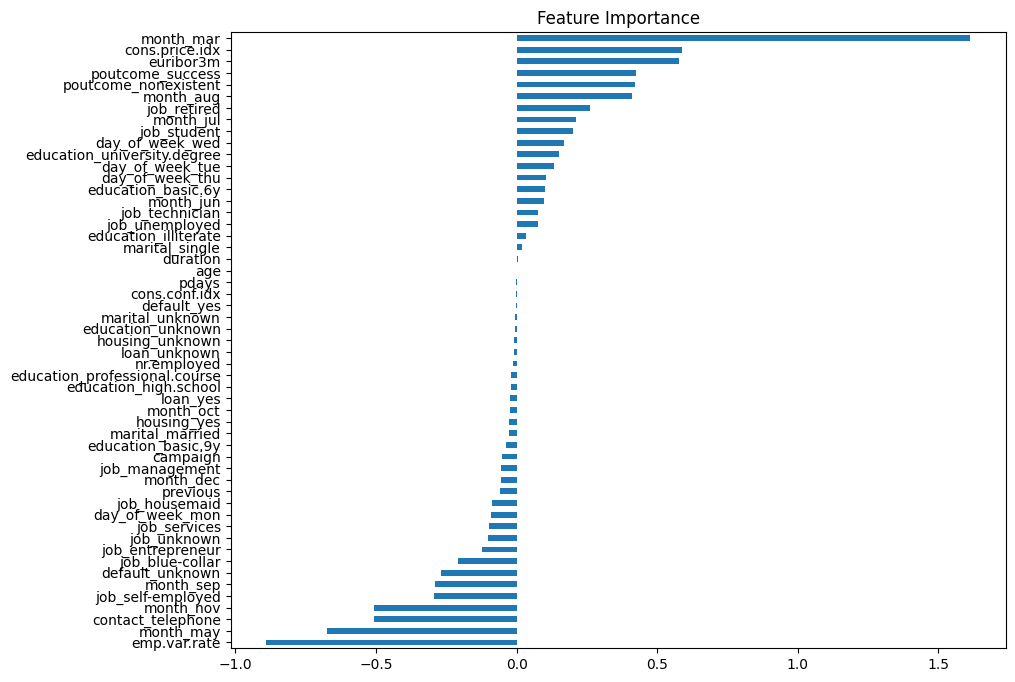

In [21]:
# Feature importance
importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values()

plt.figure(figsize=(10,8))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.